# Homework 3 Solution

1. Save a copy of this `.ipynb` file to your Google Drive or PC.  
2. Rename the file from **`HW3.ipynb`** to **`HW3_(your name).ipynb`**.  
3. Complete the code cells below by following the given instructions.  
4. Save your work and upload the `.ipynb` file to Canvas.  
   - Do **NOT** clear the outputs; leave your results visible.  
5. ⚠️ **IMPORTANT**: Convert your `.ipynb` file to a `.PDF` and upload them **together**.
    - Go to the top menu → **File → Print → Save as PDF**.  

.

.

In [1]:
!pip install PyWavelets

Defaulting to user installation because normal site-packages is not writeable


# [HW 3-1] Feature Extraction

Extract features from EXAMPLE DATASET according to following instructions:

1. Load 60 normal data and 60 abnormal data (Normal_1 ~ 60, Abnormal_1 ~ 60)
2. Extract features from acceleration and voltage signal (EXCLUDING current)
3. Extract 3 types of feature: Max, Min, Mean
4. Extract features from ONLY FREQUENCY (NOT Time) domains (WT coefficients)
5. Set the MOTHER WAVELET to 'sym3'
6. Set the wavelet decomposition level to 4


* Number of features: 3 features * 2 sensors * 4 WT levels = 24 features (per data)

* Refer to DA3_Code1

In [2]:
# Import packages from DA3_Code1
import pandas as pd
import numpy as np
import scipy.stats as sp
import pywt

# Declare the size of feature dataset
NoOfData    = 60  # Changed 180 to 60 files per condition.
NoOfSensor  = 2   # Changed 3 to 2: acceleration and voltage.
NoOfFeature = 3   # Changed 10 to 3: Max, Min, Mean.

# Load raw dataset (120 files)
for i in range(NoOfData):

    temp_path1 = f'https://github.com/ljwg3000/UNT_MEEN-AI-Fall2026/blob/main/AI_tutorial/Dataset/Normal_{i+1}?raw=true'   # File path of temporary normal data
    temp_path2 = f'https://github.com/ljwg3000/UNT_MEEN-AI-Fall2026/blob/main/AI_tutorial/Dataset/Abnormal_{i+1}?raw=true' # File path of temporary abnormal data

    exec(f"Normal_{i+1}   = pd.read_csv(temp_path1 , sep=',' , header=None)")
    exec(f"Abnormal_{i+1} = pd.read_csv(temp_path2 , sep=',' , header=None)")

# Set wavelet transform options
MotherWavelet = pywt.Wavelet('sym3')  # Changed haar to sym3; keep the lesson's variable spelling.
Level         = 4                    # Changed 8 to 4.

# Create empty(0) arrays for normal/abnormal feature dataset
FreqFeature_Normal   = np.zeros(shape=(NoOfSensor*NoOfFeature*Level , NoOfData))
FreqFeature_Abnormal = np.zeros(shape=(NoOfSensor*NoOfFeature*Level , NoOfData))

# Frequency domain feature extraction
# Kept only Max, Min, Mean; the original coefficient indexing selects d1 to d4.
for i in range(NoOfData):

    # Changed 1: to 1:3 to select acceleration and voltage only.
    exec(f"temp_data1 = Normal_{i+1}.iloc[:, 1:3]")
    exec(f"temp_data2 = Abnormal_{i+1}.iloc[:, 1:3]")

    # Wavelet decomposition
    Coef1 = pywt.wavedec(temp_data1, MotherWavelet, level=Level, axis=0)
    Coef2 = pywt.wavedec(temp_data2, MotherWavelet, level=Level, axis=0)

    # Frequency domain feature extraction
    for j in range(NoOfSensor):

        for k in range(Level):

            # Base index for rows
            base_index_sensor = NoOfFeature * Level * j
            base_index_level  = NoOfFeature * k

            base_index        = base_index_sensor + base_index_level

            # Select wavelet coefficients
            coef_normal   = Coef1[Level-k]
            coef_abnormal = Coef2[Level-k]

            signal_normal   = coef_normal[:, j]
            signal_abnormal = coef_abnormal[:, j]

            # Normal features
            FreqFeature_Normal[base_index + 0, i] = np.max(signal_normal)
            FreqFeature_Normal[base_index + 1, i] = np.min(signal_normal)
            FreqFeature_Normal[base_index + 2, i] = np.mean(signal_normal)

            # Abnormal features
            FreqFeature_Abnormal[base_index + 0, i] = np.max(signal_abnormal)
            FreqFeature_Abnormal[base_index + 1, i] = np.min(signal_abnormal)
            FreqFeature_Abnormal[base_index + 2, i] = np.mean(signal_abnormal)

# Result
FreqFeature = pd.DataFrame(np.concatenate([FreqFeature_Normal, FreqFeature_Abnormal] , axis=1))
FreqFeature


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119
0,0.184149,3.028677,1.932353e+00,0.375634,2.252443e-01,3.788099,2.105485e-01,1.821663e-01,0.391049,2.767327e-01,1.813170e-01,2.544262e+00,2.568104,2.074577e-01,1.837011e-01,1.767803e-01,1.919842e-01,0.244132,2.873404e-01,0.315279,0.228533,3.122077e-01,2.400194e-01,0.153456,0.262140,0.232700,1.556332e-01,0.218021,0.207484,5.474984e-01,0.209426,0.202710,0.312803,1.320100e-01,0.118430,0.112724,1.018752e+01,4.614715e-01,0.163135,1.710719e-01,...,0.189884,4.869071e-01,0.273518,2.459711e-01,0.584095,0.471398,0.400230,0.297968,2.837916e-01,0.562217,0.551725,0.481628,1.262469e-01,0.551324,0.474320,2.247230e-01,0.421822,0.323642,4.333996e-01,0.307867,1.904334e-01,2.022835e-01,6.217567e-01,0.537889,1.509332e-01,0.357584,0.358450,4.676376e-01,0.202488,0.307184,3.484136e-01,0.254869,0.269636,2.071461e-01,2.694586e-01,0.205938,1.511115e-01,0.653477,0.430993,2.217235e-01
1,-0.265864,-2.550634,-1.385404e+00,-0.577974,-2.030125e-01,-2.764737,-2.129329e-01,-1.886132e-01,-0.730483,-2.824382e-01,-2.518242e-01,-3.556924e+00,-4.147056,-1.230920e-01,-1.576670e-01,-2.247030e-01,-1.722578e-01,-0.253803,-3.315837e-01,-0.296264,-0.455427,-4.706285e-01,-1.787016e-01,-0.190806,-0.353978,-0.209638,-1.385282e-01,-0.176413,-0.241205,-1.013559e+00,-0.178899,-0.164018,-0.199738,-1.583501e-01,-0.160593,-0.127220,-2.189356e+01,-4.396236e-01,-0.225363,-2.888384e-01,...,-0.157789,-4.054464e-01,-0.315241,-2.614710e-01,-1.201243,-0.561060,-0.318027,-0.461784,-3.160100e-01,-0.396106,-0.342278,-0.718799,-1.219025e-01,-0.538080,-0.694566,-1.614966e-01,-0.781592,-0.918829,-6.142359e-01,-0.260019,-2.585793e-01,-1.664373e-01,-3.157357e-01,-0.579039,-1.557278e-01,-0.386349,-0.476497,-7.619375e-01,-0.329599,-0.320722,-2.544310e-01,-0.323119,-0.229521,-1.927763e-01,-1.847055e-01,-0.270301,-1.553837e-01,-0.634439,-0.544182,-2.562237e-01
2,-0.000033,-0.000006,6.071190e-06,-0.000008,2.524635e-07,-0.000008,-5.898138e-06,-8.620391e-06,0.000004,-3.919907e-06,-1.452065e-06,5.930361e-06,0.000004,-4.840536e-07,-4.118503e-07,-4.048009e-06,4.522858e-06,-0.000003,5.982566e-06,0.000008,-0.000009,4.805446e-07,1.435715e-06,-0.000006,-0.000013,-0.000002,-9.704880e-07,-0.000010,-0.000006,-4.028454e-06,-0.000009,-0.000009,-0.000007,-6.770178e-06,0.000002,-0.000012,8.061761e-07,-8.914006e-06,0.000004,-5.274709e-06,...,-0.000002,5.652729e-06,-0.000002,-8.185637e-06,0.000004,0.000011,-0.000016,-0.000017,9.796079e-07,-0.000007,-0.000004,-0.000003,-1.214727e-05,-0.000006,-0.000006,4.328722e-07,-0.000006,-0.000011,7.410452e-06,0.000005,-1.325830e-05,1.234468e-05,-1.594827e-05,-0.000012,9.046087e-07,-0.000003,-0.000009,-7.599113e-06,-0.000010,-0.000005,7.664565e-06,0.000003,-0.000007,5.415977e-06,-1.907012e-06,-0.000002,-1.258049e-05,-0.000004,-0.000005,-3.855327e-06
3,0.295879,10.394746,6.097705e+00,0.543069,1.618750e-01,5.378991,5.056858e-01,1.703103e-01,0.858650,5.547030e-01,4.466926e-01,9.509743e+00,7.331243,3.161973e-01,2.115925e-01,2.482004e-01,1.738236e-01,0.243260,4.789776e-01,0.340705,0.571515,5.163759e-01,6.013476e-01,0.173871,0.517060,0.322228,2.664006e-01,0.262382,0.401905,6.239838e-01,0.266609,0.249340,0.608566,4.715866e-01,0.560501,0.347281,1.412578e+01,3.041025e-01,0.210042,2.011899e-01,...,0.364664,5.252494e-01,0.571142,4.705488e-01,0.558027,0.847691,0.513512,0.462349,3.593824e-01,0.379302,0.291373,0.535728,1.680243e-01,0.663211,0.477552,2.030639e-01,0.650843,1.100007,8.263633e-01,0.426829,3.424541e-01,3.021596e-01,3.352636e-01,0.376572,2.217095e-01,0.318094,0.719865,2.548238e-01,0.526870,0.502251,3.378086e-01,0.751374,0.452155,4.764894e-01,1.970612e-01,0.469548,3.884165e-01,0.327160,0.350932,4.141179e-01
4,-0.314071,-9.803451,-9.275592e+00,-1.023695,-1.384551e-01,-7.208778,-7.592289e-01,-2.553250e-01,-0.430570,-4.634425e-01,-5.9204

# [HW3-2] Feature Selection

Select Top 10 discriminative features based on t-Test (p-value).
1. Conduct t-Test for each feature of `FreqFeature` above.
2. Select top 10 features that have the lowest p-values.
3. Print a dataframe of `FreqFeature_selected`.
4. Plot Probabilistic Density Functions (PDFs) of **the most discriminative feature** (normal vs. abnormal).

* Refer to DA3_Code2

(24, 60)
(24, 60)
        0          1          2    ...       117       118       119
0 -2.506974  -2.526618  -2.530612  ... -2.742994 -2.731885 -2.720834
1 -1.502469  -1.458617  -1.415731  ... -1.608090 -1.480999 -1.591330
2 -1.002901  -0.910846  -1.002135  ... -1.049674 -1.040596 -1.053665
3  1.855070   1.925444   1.907642  ...  2.059597  1.808887  1.897410
4  1.573458   1.711238   1.326702  ...  1.982697  1.940524  1.679061
5  2.517256   3.137764   2.960781  ...  3.873784  3.688512  3.138267
6 -2.005910  -1.866544  -1.867477  ... -2.014453 -1.734221 -1.957553
7 -1.014618 -38.376000 -45.419020  ... -0.470001 -1.242952 -0.910442
8  0.686736  43.505384  35.751685  ...  0.558545  1.050780  0.634139
9  1.698164  11.412023  15.043403  ...  0.914390  0.994327  0.912756

[10 rows x 120 columns]


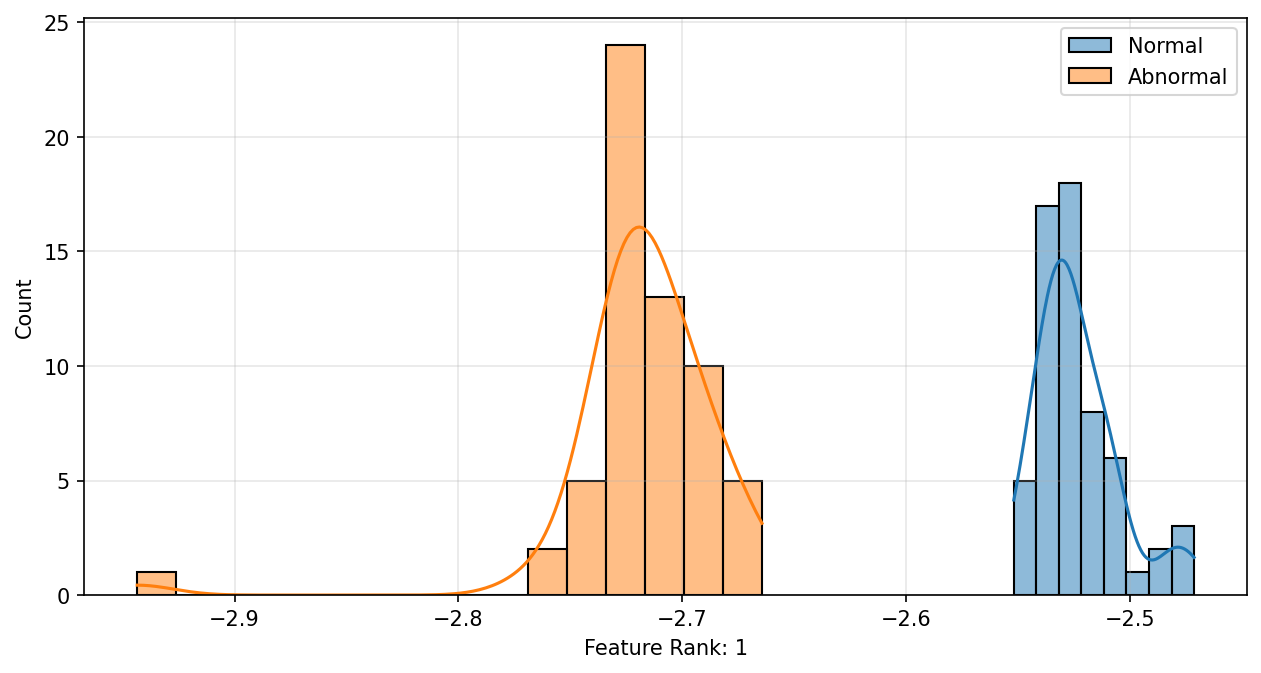

In [3]:
# Import additional plotting packages from DA3_Code2
import seaborn as sb
import matplotlib.pyplot as plt

# Use the HW3-1 result instead of loading FeatureData.csv from Google Drive.
FeatureData = FreqFeature

# Get p-values by conducting t-Test
NoOfData = int(FeatureData.shape[1]/2)  # int function: convert float to integer
Normal_FeatureData   = FeatureData.iloc[:,:NoOfData]
Abnormal_FeatureData = FeatureData.iloc[:,NoOfData:]

print(Normal_FeatureData.shape)
print(Abnormal_FeatureData.shape)

NoOfFeature = FeatureData.shape[0] # Number of features: 24

P_value = np.zeros((NoOfFeature , 2))

# t-Test (Result: p-value)
for i in np.arange(NoOfFeature):

    T_test       = np.array(sp.ttest_ind(Normal_FeatureData.iloc[i,:] , Abnormal_FeatureData.iloc[i,:]))
    P_value[i,0] = i          # Index of feature (0~23)
    P_value[i,1] = T_test[1]  # P-value

P_value = pd.DataFrame(P_value, columns=['No.', 'P-value'])

# Sort by P-value in ascending order
P_value_Rank = P_value.sort_values(['P-value'], ascending=True)

# Select top 10 features
Rank = 10  # Changed 30 to 10 selected features.

Normal   = np.zeros((Rank,NoOfData))
Abnormal = np.zeros((Rank,NoOfData))

for i in range(Rank):

    index         = int(P_value_Rank.iloc[i,0])
    Normal[i,:]   = Normal_FeatureData.iloc[index,:].values
    Abnormal[i,:] = Abnormal_FeatureData.iloc[index,:].values

FreqFeature_selected = pd.DataFrame(np.concatenate([Normal, Abnormal] , axis=1))
print(FreqFeature_selected)

# Plot Probabilistic Density Functions (PDFs)
# P-value Rank (0 ~ 23)
FeatureRank = 0

# PDF Chart
plt.figure(figsize=(10,5))
sb.histplot(Normal_FeatureData.iloc[int(P_value_Rank.iloc[FeatureRank,0])  ,:], kde=True, label = 'Normal')
sb.histplot(Abnormal_FeatureData.iloc[int(P_value_Rank.iloc[FeatureRank,0]),:], kde=True, label = 'Abnormal')
plt.legend(loc='best', fontsize=10)
plt.xlabel(f'Feature Rank: {FeatureRank+1}')
plt.grid(alpha=0.3)
plt.show()
